Very WIP notebooks to help finish up the project.

In [2]:
import os
os.chdir("/home/smestern/patchotda/")
import streamlit as st
import pandas as pd
import numpy as np
from concurrent import futures
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from hiclass import LocalClassifierPerNode, LocalClassifierPerParentNode, LocalClassifierPerLevel
from sklearn.base import BaseEstimator, ClassifierMixin
#import XGBoost as xgb
#other
import altair as alt
import time
import zipfile
from utils import MMS_DATA, USER_DATA, EXAMPLE_DATA_, REF_DATA_, VISp_MET_nodes, VISp_T_nodes, filter_MMS, find_outlier_idxs, param_grid_from_dict, select_by_col, not_select_by_col, CLASS_MODELS, HICLASS_METHOD

import os
from patchOTDA.external import skada
from patchOTDA.domainAdapt import PatchClampOTDA, timeout
from functools import partial
import ot.da
from ot.backend import get_backend
import umap
from streamlit_tree_select import tree_select
import xgboost as xgb
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import NearMiss, EditedNearestNeighbours
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline

labels="VISp_T"
hiclass_method = "LocalClassifierPerNode"
class_model = "Random Forest"


/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-17 08:40:18.311 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [3]:
ref_data = MMS_DATA['VISp_Viewer']
ref_data_ephys, ref_data_meta = ref_data['ephys'], ref_data['meta']
Xs, Ys = ref_data_ephys.to_numpy(), ref_data_meta[[labels+"_1_en", labels+"_2_en", labels+"_3_en"]]
Ys = Ys.to_numpy()
assert Xs.shape[0] == Ys.shape[0], "Number of samples in Xs and Ys must be the same"

In [4]:

Ys_combined = [f"{y1}_{y2}_{y3}" for y1, y2, y3 in zip(Ys[:, 0], Ys[:, 1], Ys[:, 2])]
print(Counter(Ys_combined))
counter = Counter(Ys_combined)
labels_to_drop = [label for label, count in counter.items() if count < 15]
drop_idxs = [i for i, label in enumerate(Ys_combined) if label in labels_to_drop]
print(f"Dropping {len(drop_idxs)} samples with labels: {set(labels_to_drop)}")
print(f"Original dataset size: {len(Ys)}, New dataset size: {len(Ys) - len(drop_idxs)}")
Xs = np.delete(Xs, drop_idxs, axis=0)
Ys = np.delete(Ys, drop_idxs, axis=0)
# Recompute combined labels after dropping (needed for stratified split)
Ys_combined = [f"{y1}_{y2}_{y3}" for y1, y2, y3 in zip(Ys[:, 0], Ys[:, 1], Ys[:, 2])]


Counter({'4_20_24': 272, '4_26_31': 254, '1_10_11': 242, '0_3_4': 201, '1_13_15': 177, '1_11_13': 177, '4_25_30': 146, '0_5_6': 142, '4_31_39': 141, '3_19_21': 134, '4_21_25': 131, '5_43_56': 128, '4_24_29': 117, '4_33_43': 111, '5_37_48': 107, '5_44_57': 98, '4_31_38': 97, '5_42_55': 90, '0_4_5': 74, '1_6_7': 64, '4_27_33': 63, '5_35_45': 62, '4_28_34': 60, '4_32_40': 59, '4_26_32': 58, '4_20_23': 57, '1_12_14': 55, '5_36_46': 53, '4_32_41': 52, '3_17_19': 49, '5_37_47': 48, '1_8_9': 46, '4_30_37': 46, '5_46_59': 44, '1_10_12': 44, '4_23_28': 43, '5_42_54': 39, '4_29_36': 38, '3_19_22': 38, '1_7_8': 38, '5_34_44': 38, '2_15_17': 35, '5_41_53': 30, '4_33_42': 29, '1_9_10': 25, '1_14_16': 23, '0_0_1': 22, '5_38_49': 20, '5_39_50': 19, '0_2_3': 19, '4_22_26': 18, '4_28_35': 17, '2_16_18': 12, '0_1_2': 12, '3_18_20': 12, '4_22_27': 10, '5_45_58': 10, '5_40_51': 6, '0_0_0': 6, '5_40_52': 2})
Dropping 70 samples with labels: {'4_22_27', '5_45_58', '2_16_18', '3_18_20', '0_1_2', '5_40_52', '

In [5]:
Xs_train, Xs_test, Ys_train, Ys_test = train_test_split(Xs, Ys, test_size=0.2, random_state=42, stratify=Ys_combined)


Xs_train shape: (3352, 29)
Ys_train shape: (3352, 3)
Xs_train_resampled shape: (6732, 29)


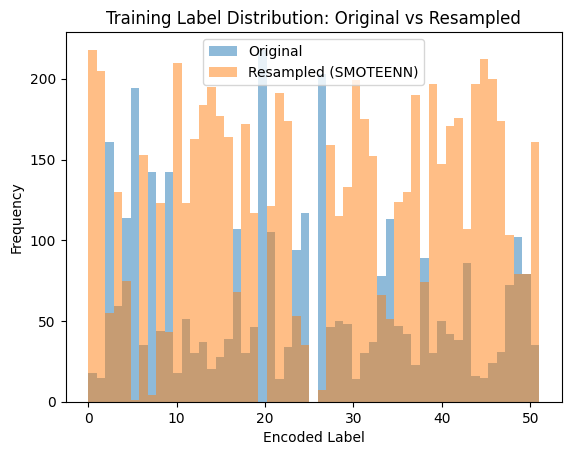

In [6]:
impute_and_scale = Pipeline([('imputer', KNNImputer()), ('scaler', StandardScaler())])
Xs_train = impute_and_scale.fit_transform(Xs_train)
Xs_test = impute_and_scale.transform(Xs_test)
Xs = impute_and_scale.transform(Xs)


# SMOTEENN is now applied inside the CV loop in error_func and before final training,
# NOT here, to avoid data leakage during cross-validation.
# We still prepare the combined labels and encoder for the final resampling step.
Ys_train_combined = [f"{y[0]}_{y[1]}_{y[2]}" for y in Ys_train]
Ys_test_combined = [f"{y[0]}_{y[1]}_{y[2]}" for y in Ys_test]
Ys_combined_all = [f"{y[0]}_{y[1]}_{y[2]}" for y in Ys]

#encode the combined labels
label_encoder = LabelEncoder()
Ys_train_encoded = label_encoder.fit_transform(Ys_train_combined)
Ys_test_encoded = label_encoder.transform(Ys_test_combined)
Ys_encoded = label_encoder.transform(Ys_combined_all)

# Apply SMOTEENN for final model training only (not used for CV inside error_func)
SMOTE_EEN = SMOTEENN(sampling_strategy='auto',smote=SMOTE(random_state=42,k_neighbors=5), enn=EditedNearestNeighbours( n_neighbors=5))
Xs_train_resampled, Ys_train_resampled = SMOTE_EEN.fit_resample(Xs_train, Ys_train_encoded)

#decode the resampled labels back to the original format
Ys_train_resampled_decoded = label_encoder.inverse_transform(Ys_train_resampled)

##split the decoded labels back into the 3 levels of the hierarchy
Ys_train_resampled_decoded_split = np.array([y.split("_") for y in Ys_train_resampled_decoded]).astype(np.int32)

print(f"Xs_train shape: {Xs_train.shape}")
print(f"Ys_train shape: {Ys_train.shape}")
print(f"Xs_train_resampled shape: {Xs_train_resampled.shape}")

plt.hist(Ys_train_encoded, bins=len(label_encoder.classes_)+1, alpha=0.5, label="Original")
plt.hist(Ys_train_resampled, bins=len(label_encoder.classes_)+1, alpha=0.5, label="Resampled (SMOTEENN)")
plt.title("Training Label Distribution: Original vs Resampled")
plt.xlabel("Encoded Label")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:

import nevergrad as ng
# we can adjust these weights to give more importance to certain levels of the hierarchy
ACCURACY_LEVEL_WEIGHTS = [0.2, 0.3, 0.5]
# normalize the weights to sum to 1, just for sanity
ACCURACY_LEVEL_WEIGHTS = np.array(
    ACCURACY_LEVEL_WEIGHTS) / np.sum(ACCURACY_LEVEL_WEIGHTS)


def error_func(Xs_train, Ys_train, params):
    """Cross-validated error function with SMOTEENN applied inside each fold to prevent data leakage."""
    himethod = HICLASS_METHOD[params['HICLASS_METHOD']]
    # Don't use .pop() — it mutates the nevergrad param dict and breaks subsequent calls
    model_cls = params['inner_model']['model']
    model_params = {k: v for k, v in params['inner_model'].items() if k != 'model'}

    # Combine labels for stratification and SMOTE encoding
    Ys_combined_cv = [f"{y[0]}_{y[1]}_{y[2]}" for y in Ys_train]
    le_cv = LabelEncoder()
    Ys_encoded_cv = le_cv.fit_transform(Ys_combined_cv)

    # 5-fold cross validation with SMOTEENN inside the fold
    error = []
    for x in range(5):
        Xs_tr, Xs_val, Ys_tr, Ys_val, Ye_tr, _ = train_test_split(
            Xs_train, Ys_train, Ys_encoded_cv,
            test_size=0.33, random_state=x, shuffle=True, stratify=Ys_encoded_cv)

        # Apply SMOTEENN inside the fold to prevent leakage
        smote_enn = SMOTEENN(
            sampling_strategy='auto',
            smote=SMOTE(random_state=42, k_neighbors=5),
            enn=EditedNearestNeighbours(n_neighbors=5))
        try:
            Xs_tr_res, Ye_tr_res = smote_enn.fit_resample(Xs_tr, Ye_tr)
            Ys_tr_res = np.array([s.split("_") for s in le_cv.inverse_transform(Ye_tr_res)]).astype(np.int32)
        except ValueError:
            # If SMOTE fails (too few samples in a class), fall back to unbalanced
            Xs_tr_res, Ys_tr_res = Xs_tr, Ys_tr

        model = himethod(model_cls(**model_params))
        model.fit(Xs_tr_res, Ys_tr_res.astype(np.int32))
        Ys_pred = model.predict(Xs_val)
        # for each level, calculate the balanced accuracy score and average them
        temp_error = []
        for level in np.arange(Ys_val.shape[1]):
            temp_error.append(ACCURACY_LEVEL_WEIGHTS[level] * balanced_accuracy_score(
                Ys_val[:, level].astype(np.int32), Ys_pred[:, level].astype(np.int32)))
        error.append(np.sum(temp_error))
    # we return 1 - the error because the optimizer minimizes the error, but we want to maximize the accuracy
    return 1-(np.mean(error))


# make a nevergrad optimizer


param_space = ng.p.Dict(**{'HICLASS_METHOD': ng.p.Choice(['LocalClassifierPerNode', 'LocalClassifierPerParentNode', 'LocalClassifierPerLevel']),
                           # inner model
                           "inner_model": ng.p.Choice([
                               # HistGradientBoostingClassifier
                               ng.p.Dict(**{'model': HistGradientBoostingClassifier,
                                            'learning_rate': ng.p.Log(lower=0.001, upper=1),
                                            'l2_regularization': ng.p.Log(lower=1e-2, upper=5),
                                            'min_samples_leaf': ng.p.Scalar(lower=1, upper=100).set_integer_casting(),
                                            'max_depth': ng.p.TransitionChoice(choices=[*np.arange(1, 31).tolist(), None]),
                                            'max_features': ng.p.Scalar(lower=0.001, upper=1),
                                            'max_leaf_nodes': ng.p.TransitionChoice(choices=[*np.arange(2, 500, 5).tolist(), None]),
                                            'class_weight': ng.p.Choice(['balanced', None]),
                                            }),
                               # RandomForestClassifier
                               ng.p.Dict(**{'model': RandomForestClassifier,
                                            'n_estimators': ng.p.Scalar(lower=50, upper=1000).set_integer_casting(),
                                            'min_samples_split': ng.p.Scalar(lower=0.001, upper=0.3),
                                            'min_samples_leaf': ng.p.Scalar(lower=0.001, upper=0.15),
                                            'min_impurity_decrease': ng.p.Log(lower=1e-4, upper=0.1),
                                            'max_depth': ng.p.TransitionChoice(choices=[*np.arange(3, 31).tolist(), None]),
                                            'max_features': ng.p.Choice(['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]),
                                            'class_weight': ng.p.Choice(['balanced', 'balanced_subsample', None]),
                                            }),
                               # ExtraTreesClassifier
                               ng.p.Dict(**{'model': ExtraTreesClassifier,
                                            'n_estimators': ng.p.Scalar(lower=50, upper=1000).set_integer_casting(),
                                            'min_samples_split': ng.p.Scalar(lower=0.001, upper=0.3),
                                            'min_samples_leaf': ng.p.Scalar(lower=0.001, upper=0.15),
                                            'min_impurity_decrease': ng.p.Log(lower=1e-4, upper=0.1),
                                            'max_depth': ng.p.TransitionChoice(choices=[*np.arange(3, 31).tolist(), None]),
                                            'max_features': ng.p.Choice(['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]),
                                            'class_weight': ng.p.Choice(['balanced', 'balanced_subsample', None]),
                                            }),
                               # # XGBClassifier — strong multiclass, handles imbalance
                               ng.p.Dict(**{'model': xgb.XGBClassifier,
                                            'n_estimators': ng.p.Scalar(lower=50, upper=1000).set_integer_casting(),
                                            'learning_rate': ng.p.Log(lower=0.001, upper=0.5),
                                            'max_depth': ng.p.Scalar(lower=2, upper=15).set_integer_casting(),
                                            'reg_alpha': ng.p.Log(lower=1e-4, upper=10),
                                            'reg_lambda': ng.p.Log(lower=1e-4, upper=10),
                                            'subsample': ng.p.Scalar(lower=0.5, upper=1.0),
                                            'colsample_bytree': ng.p.Scalar(lower=0.3, upper=1.0),
                                            'min_child_weight': ng.p.Scalar(lower=1, upper=20).set_integer_casting(),
                                            'verbosity': 0,
                                            }),
                               # AdaBoostClassifier — kept but lower priority, weaker for many classes
                               ng.p.Dict(**{'model': AdaBoostClassifier,
                                            'n_estimators': ng.p.Scalar(lower=50, upper=500).set_integer_casting(),
                                            'learning_rate': ng.p.Log(lower=0.01, upper=1),
                                            }),
                           ])})


optimizer = ng.optimizers.Portfolio(
    parametrization=param_space, budget=100, num_workers=6,)

#run the optimizer — now pass ORIGINAL (non-resampled) training data so SMOTE happens inside each CV fold
with futures.ThreadPoolExecutor(max_workers=6) as executor:
    recommendation = optimizer.minimize(partial(error_func, Xs_train, Ys_train),  executor=executor, batch_mode=False,verbosity=2, max_time=1*60*60)
    #5 hours max time, we can adjust this as needed, but we want to give it enough time to explore the space, especially with the larger models and the cross validation


Launching 6 jobs with new suggestions


/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWar

Updating fitness with value 0.6935316203385452
94 remaining budget and 5 running jobs
Current pessimistic best is: MultiValue<mean: 0.6935316203385452, count: 1, parameter: Dict(HICLASS_METHOD=Choice(choices=Tuple(LocalClassifierPerNode,LocalClassifierPerParentNode,LocalClassifierPerLevel),indices=Array{(1,3),SoftmaxSampling}),inner_model=Choice(choices=Tuple(Dict(class_weight=Choice(choices=Tuple(balanced,None),indices=Array{(1,2),SoftmaxSampling}),l2_regularization=Log{Cl(-4.4461405575910256,1.553859442408974,b),exp=2.82},learning_rate=Log{Cl(-6,0,b),exp=3.16},max_depth=TransitionChoice(choices=Tuple(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,None),indices=Array{Cd(0,31),Add,Int},transitions=[1. 1.]),max_features=Scalar{Cl(0.001,1,b)}[sigma=Scalar{exp=2.03}],max_leaf_nodes=TransitionChoice(choices=Tuple(2,7,12,17,22,27,32,37,42,47,52,57,62,67,72,77,82,87,92,97,102,107,112,117,122,127,132,137,142,147,152,157,162,167,172,177,182,187,192,197,202,207

/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWar

Updating fitness with value 0.6542448940116743
93 remaining budget and 5 running jobs
Current pessimistic best is: MultiValue<mean: 0.6542448940116743, count: 1, parameter: Dict(HICLASS_METHOD=Choice(choices=Tuple(LocalClassifierPerNode,LocalClassifierPerParentNode,LocalClassifierPerLevel),indices=Array{(1,3),SoftmaxSampling}),inner_model=Choice(choices=Tuple(Dict(class_weight=Choice(choices=Tuple(balanced,None),indices=Array{(1,2),SoftmaxSampling}),l2_regularization=Log{Cl(-4.4461405575910256,1.553859442408974,b),exp=2.82},learning_rate=Log{Cl(-6,0,b),exp=3.16},max_depth=TransitionChoice(choices=Tuple(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,None),indices=Array{Cd(0,31),Add,Int},transitions=[1. 1.]),max_features=Scalar{Cl(0.001,1,b)}[sigma=Scalar{exp=2.03}],max_leaf_nodes=TransitionChoice(choices=Tuple(2,7,12,17,22,27,32,37,42,47,52,57,62,67,72,77,82,87,92,97,102,107,112,117,122,127,132,137,142,147,152,157,162,167,172,177,182,187,192,197,202,207

/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)
/home/smestern/miniconda3/envs/patchotda/lib/python3.11/site-packages/xgboost/core.py:748: FutureWar

In [ ]:
# best_val = recommendation.value
# himethod = best_val.pop('HICLASS_METHOD')
# inner_model = best_val.pop('inner_model')
# model_method = inner_model.pop('model')

# print(f"Selected HICLASS method: {himethod}")
# print(f"Selected inner model: {model_method}")
# print(f"Parameters of the inner model: {inner_model}")

himethod = "LocalClassifierPerParentNode"
model_method  = HistGradientBoostingClassifier
best_val = {'learning_rate': 0.07073962079574285, 'l2_regularization': 0.1897593628100637, 'min_samples_leaf': 18, 'max_depth': 24, 'max_features': 0.3879350909851048, 'max_leaf_nodes': 182, 'class_weight': 'balanced'}

In [ ]:
#reinit the model and train on  the full dataset
model = HICLASS_METHOD[himethod](model_method(**best_val))
model.fit(Xs_train_resampled, Ys_train_resampled_decoded_split)


LocalClassifierPerParentNode(local_classifier=HistGradientBoostingClassifier(class_weight='balanced',
                                                                             l2_regularization=0.1897593628100637,
                                                                             learning_rate=0.07073962079574285,
                                                                             max_depth=24,
                                                                             max_features=0.3879350909851048,
                                                                             max_leaf_nodes=182,
                                                                             min_samples_leaf=18))

In [ ]:
Ys_pred = model.predict(Xs_test)
Ys_pred_train = model.predict(Xs_train_resampled)

#test the 3 levels of the model
dict_results = {"Train (resampled)":[], "Test":[]}
for level in [0,1,2]:
    dict_results["Train (resampled)"].append(balanced_accuracy_score(Ys_train_resampled_decoded_split[:,level].astype(np.int32), Ys_pred_train[:,level].astype(np.int32)))
    dict_results["Test"].append(balanced_accuracy_score(Ys_test[:,level].astype(np.int32), Ys_pred[:,level].astype(np.int32)))


In [ ]:
print(dict_results)

{'Train': [0.8971307639220681, 0.7158926355071589, 0.6971720560403998], 'Test': [0.6958562303889478, 0.3442053187935115, 0.3241784298752324]}


In [ ]:
label_encoder = MMS_DATA['VISp_Viewer'].keys()
print(label_encoder)

dict_keys(['ephys', 'meta', 'VISp_MET_LE_1', 'VISp_MET_LE_2', 'VISp_MET_LE_3', 'VISp_T_LE_1', 'VISp_T_LE_2', 'VISp_T_LE_3'])


In [ ]:
#create a confusion matrix for each level
from sklearn.metrics import ConfusionMatrixDisplay
output_dir = "/home/smestern/pypatchOTDA/tests/"
confusion_matrices = []
for level in [0,1,2]:
    label_encoder = MMS_DATA['VISp_Viewer'][f'VISp_T_LE_{level+1}']
    confusion_matrices.append(confusion_matrix(label_encoder.inverse_transform(Ys_test[:,level].astype(np.int32)), label_encoder.inverse_transform(Ys_pred[:,level].astype(np.int32)), labels=label_encoder.classes_, normalize='true'))
    #save as a dataframe csv
    pd.DataFrame(confusion_matrices[-1], columns=label_encoder.classes_, index=label_encoder.classes_).to_csv(os.path.join(output_dir, f"confusion_matrix_{level}.csv"))


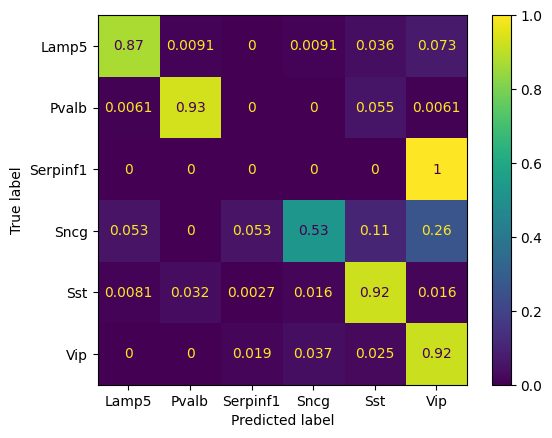

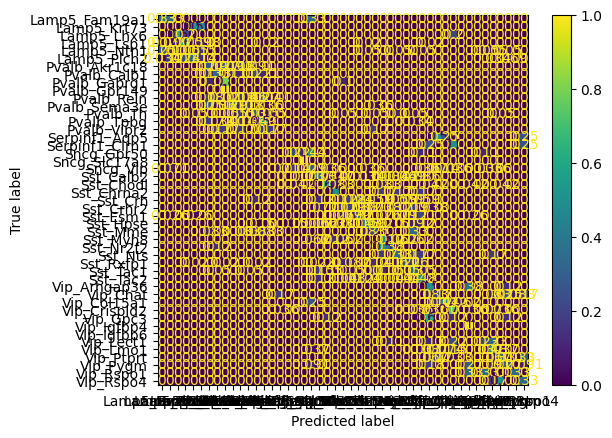

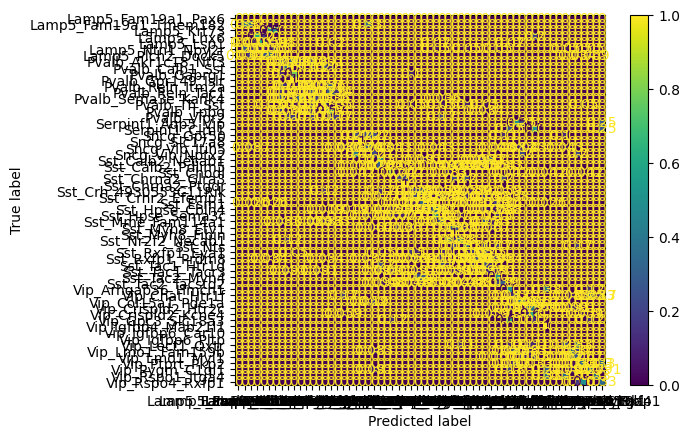

In [ ]:
#display the confusion matrices
import matplotlib.pyplot as plt
for level in [0,1,2]:
    label_encoder = MMS_DATA['VISp_Viewer'][f'VISp_T_LE_{level+1}']
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrices[level], display_labels=label_encoder.classes_)
    disp.plot()
    plt.savefig(os.path.join(output_dir, f"confusion_matrix_{level}.png"))
